# MVP: Radial concrete model for one equivalent CTES element

This notebook strips the problem down to the part you want to understand first:

- one **equivalent cylindrical concrete element** around one pipe,
- no fluid model yet,
- no axial coupling yet,
- just the **radial heat diffusion** in the concrete.

The key idea is to replace the PDE with a small set of **energy balances on concentric concrete shells**. Each shell has:

- a volume, so it can store energy,
- an inner and outer interface area, so heat can flow through it,
- one average temperature that changes over time.

That gives you a model Python can handle directly.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.constants import rho_con, Cp_con, lambda_con, D_ext, V_con, n_modules, module_length

alpha_con = lambda_con / (rho_con * Cp_con)

print(f'rho_con   = {rho_con} kg/m^3')
print(f'Cp_con    = {Cp_con} J/(kg K)')
print(f'lambda    = {lambda_con} W/(m K)')
print(f'alpha     = {alpha_con:.3e} m^2/s')


rho_con   = 2340 kg/m^3
Cp_con    = 920 J/(kg K)
lambda    = 1.4 W/(m K)
alpha     = 6.503e-07 m^2/s


## 1. Turn the PDE into shell balances

After dropping axial conduction, the concrete equation is

$$\rho_{con} C_{p,con} \frac{\partial T}{\partial t} = \frac{\lambda_{con}}{r}\frac{\partial}{\partial r}\left(r\frac{\partial T}{\partial r}\right)$$

Definitions:

- $\rho_{con}$ [kg/m^3]: density of the concrete.
- $C_{p,con}$ [J/(kg K)]: specific heat capacity of the concrete.
- $T$ [degC or K]: temperature in the concrete.
- $t$ [s]: time.
- $\lambda_{con}$ [W/(m K)]: thermal conductivity of the concrete.
- $r$ [m]: radial distance from the center of the pipe.

Instead of solving that directly, as our computer can't work with continuous values, we divide the concrete annulus into `N` radial shells.

Definition:

- $N$: number of radial shells.

For shell $i$, the volume is

$$V_i = \pi\left(r_{i+1/2}^2 - r_{i-1/2}^2\right)L$$

Definitions:

- $V_i$ [m^3]: volume of shell $i$.
- $i$: shell index.
- $r_{i-1/2}$ [m]: inner radius of shell $i$.
- $r_{i+1/2}$ [m]: outer radius of shell $i$.
- $L$ [m]: axial length represented by the slice.
- $\pi$: the constant 3.14159...

This works because a shell is a hollow cylinder, so its volume is outer-circle area minus inner-circle area, multiplied by length.

The cylindrical face area at radius $r_{i+1/2}$ is

$$A_{i+1/2} = 2\pi r_{i+1/2}L$$

Definitions:

- $A_{i+1/2}$ [m^2]: area of the cylindrical face at radius $r_{i+1/2}$.
- $2\pi r_{i+1/2}$ [m]: circumference at that radius.
- $L$ [m]: axial length represented by the slice.

Then the PDE becomes an ordinary energy balance:

$$\rho_{con} C_{p,con} V_i \frac{dT_i}{dt} = \dot Q_{i-1/2} - \dot Q_{i+1/2}$$

Definitions:

- $T_i$ [degC or K]: average temperature of shell $i$.
- $\frac{dT_i}{dt}$ [K/s or degC/s]: rate of temperature change of shell $i$.
- $\dot Q_{i-1/2}$ [W]: heat rate entering shell $i$ through the inner face.
- $\dot Q_{i+1/2}$ [W]: heat rate leaving shell $i$ through the outer face.

The conductive heat rate between shell $i$ and shell $i+1$ is

$$\dot Q_{i+1/2} = \lambda_{con} A_{i+1/2}\frac{T_i - T_{i+1}}{r_{i+1} - r_i}$$

Definitions:

- $T_i$ [degC or K]: temperature of shell $i$.
- $T_{i+1}$ [degC or K]: temperature of the next shell outward.
- $r_i$ [m]: center radius of shell $i$.
- $r_{i+1}$ [m]: center radius of shell $i+1$.
- $r_{i+1} - r_i$ [m]: distance between the shell centers.

Here, positive $\dot Q$ means heat goes from smaller radius to larger radius.

For the inner boundary, we temporarily impose a known wall temperature:

$$\dot Q_{1/2} = \lambda_{con} A_{1/2}\frac{T_{wall} - T_0}{r_0 - r_{1/2}}$$

Definitions:

- $\dot Q_{1/2}$ [W]: heat rate from the pipe wall into the first concrete shell.
- $T_{wall}$ [degC or K]: pipe-wall temperature.
- $T_0$ [degC or K]: temperature of the first shell.
- $r_{1/2}$ [m]: radius of the wall-concrete boundary.
- $r_0$ [m]: center radius of the first shell.

For the outer boundary, this MVP uses an insulated boundary:

$$\dot Q_{N+1/2} = 0$$

Definitions:

- $\dot Q_{N+1/2}$ [W]: heat rate through the outermost boundary.
- Setting it to 0 means no heat crosses the outer boundary.

Finally, discretize time with explicit Euler:

$$T_i^{n+1} = T_i^n + \frac{\Delta t}{\rho_{con} C_{p,con} V_i}\left(\dot Q_{i-1/2}^n - \dot Q_{i+1/2}^n\right)$$

Definitions:

- $T_i^n$: temperature of shell $i$ at time step $n$.
- $T_i^{n+1}$: temperature of shell $i$ at the next time step.
- $\Delta t$ [s]: time-step length.
- $\dot Q_{i-1/2}^n$ [W]: inner-face heat rate evaluated at time step $n$.
- $\dot Q_{i+1/2}^n$ [W]: outer-face heat rate evaluated at time step $n$.

This is the core implementation you can later couple to the fluid model.

In [2]:
# Geometry for one representative concrete element around one pipe
#
# The only geometric input you may not know yet is n_pipes.
# Treat it as a model input. Once the real layout is fixed, replace it.

n_pipes = 818          # estimate reused from the fuller charging notebook
n_shells = 10          # number of concrete control volumes in the radial direction
slice_length = 1.0     # m of pipe represented by this radial slice

V_module = V_con / n_modules
A_module_concrete = V_module / module_length
A_eq = A_module_concrete / n_pipes

r_inner = D_ext / 2.0
r_outer = np.sqrt(A_eq / np.pi)

faces = np.linspace(r_inner, r_outer, n_shells + 1)
centers = 0.5 * (faces[:-1] + faces[1:])
dr = np.diff(faces)

A_faces = 2.0 * np.pi * faces * slice_length
V_shells = np.pi * (faces[1:]**2 - faces[:-1]**2) * slice_length

print(f'Equivalent concrete area per pipe  = {A_eq:.6f} m^2')
print(f'Concrete inner radius              = {r_inner*1e3:.2f} mm')
print(f'Equivalent outer radius            = {r_outer*1e3:.2f} mm')
print(f'Radial shell width                 = {dr[0]*1e3:.2f} mm')
print(f'Total represented concrete volume  = {V_shells.sum():.6f} m^3')


Equivalent concrete area per pipe  = 0.006399 m^2
Concrete inner radius              = 12.50 mm
Equivalent outer radius            = 45.13 mm
Radial shell width                 = 3.26 mm
Total represented concrete volume  = 0.005908 m^3


In [3]:
def interface_heat_rates(T_shells, T_wall, A_faces, faces, centers, conductivity):
    """
    Return heat rates [W] at every radial face.

    Convention:
    - Q[k] is heat flowing from smaller radius to larger radius.
    - Q[0] is wall -> first shell.
    - Q[-1] is the outer boundary loss. In this MVP it is zero (insulated).
    """
    n = len(T_shells)
    Q = np.zeros(n + 1)

    # Inner boundary: prescribed wall temperature
    Q[0] = conductivity * A_faces[0] * (T_wall - T_shells[0]) / (centers[0] - faces[0])

    # Interior shell-to-shell conduction
    for i in range(1, n):
        distance = centers[i] - centers[i - 1]
        Q[i] = conductivity * A_faces[i] * (T_shells[i - 1] - T_shells[i]) / distance

    # Outer boundary: insulated for the MVP
    Q[-1] = 0.0
    return Q


def explicit_euler_step(T_shells, T_wall, dt, rho, cp, conductivity, V_shells, A_faces, faces, centers):
    Q = interface_heat_rates(T_shells, T_wall, A_faces, faces, centers, conductivity)
    dE_dt = Q[:-1] - Q[1:]
    dT_dt = dE_dt / (rho * cp * V_shells)
    T_next = T_shells + dt * dT_dt
    return T_next, Q, dE_dt


def simulate_radial_concrete(T_init, T_wall, t_end, dt, rho, cp, conductivity, V_shells, A_faces, faces, centers):
    n_steps = int(np.ceil(t_end / dt))
    times = np.arange(n_steps + 1) * dt
    T_hist = np.zeros((n_steps + 1, len(T_init)))
    Q_hist = np.zeros((n_steps, len(T_init) + 1))
    shell_power_hist = np.zeros((n_steps, len(T_init)))

    T_hist[0] = T_init.copy()
    T = T_init.copy()

    for n in range(n_steps):
        T, Q, shell_power = explicit_euler_step(
            T_shells=T,
            T_wall=T_wall,
            dt=dt,
            rho=rho,
            cp=cp,
            conductivity=conductivity,
            V_shells=V_shells,
            A_faces=A_faces,
            faces=faces,
            centers=centers,
        )
        T_hist[n + 1] = T
        Q_hist[n] = Q
        shell_power_hist[n] = shell_power

    return times, T_hist, Q_hist, shell_power_hist


In [4]:
# Example case: suddenly expose the pipe wall to a higher temperature

T_initial = np.full(n_shells, 20.0)
T_wall = 90.0
t_end = 2.0 * 3600.0

# A conservative explicit-Euler time step.
# The smallest shell width controls stability most strongly.
dt_limit = 0.4 * np.min(dr)**2 / alpha_con
dt = min(1.0, 0.5 * dt_limit)

times, T_hist, Q_hist, shell_power_hist = simulate_radial_concrete(
    T_init=T_initial,
    T_wall=T_wall,
    t_end=t_end,
    dt=dt,
    rho=rho_con,
    cp=Cp_con,
    conductivity=lambda_con,
    V_shells=V_shells,
    A_faces=A_faces,
    faces=faces,
    centers=centers,
)

print(f'Estimated explicit stability limit: dt < {dt_limit:.2f} s')
print(f'Chosen dt:                        {dt:.2f} s')
print('')
print('Heat rates at the very first time step [W]:')
print(np.round(Q_hist[0], 2))
print('')
print('Energy added to each shell during the first step [J]:')
print(np.round(shell_power_hist[0] * dt, 2))
print('')
print(f'Innermost shell temperature after 2 h: {T_hist[-1, 0]:.2f} C')
print(f'Outermost shell temperature after 2 h: {T_hist[-1, -1]:.2f} C')


Estimated explicit stability limit: dt < 6.55 s
Chosen dt:                        1.00 s

Heat rates at the very first time step [W]:
[4717.61    0.      0.      0.      0.      0.      0.      0.      0.
    0.      0.  ]

Energy added to each shell during the first step [J]:
[4717.61    0.      0.      0.      0.      0.      0.      0.      0.
    0.  ]

Innermost shell temperature after 2 h: 89.98 C
Outermost shell temperature after 2 h: 89.86 C


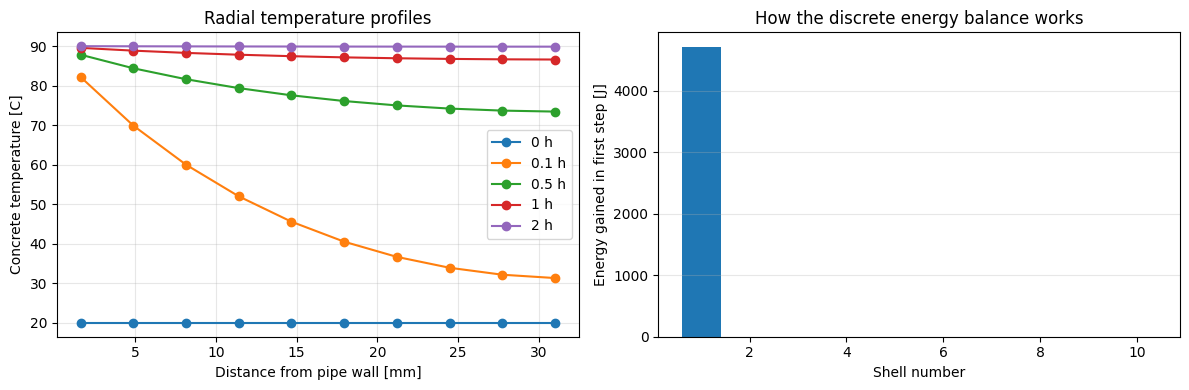

In [5]:
r_from_wall_mm = (centers - r_inner) * 1e3

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for t_hours in [0.0, 0.1, 0.5, 1.0, 2.0]:
    idx = min(int(round(t_hours * 3600.0 / dt)), len(times) - 1)
    axes[0].plot(r_from_wall_mm, T_hist[idx], marker='o', label=f'{t_hours:g} h')

axes[0].set_xlabel('Distance from pipe wall [mm]')
axes[0].set_ylabel('Concrete temperature [C]')
axes[0].set_title('Radial temperature profiles')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(np.arange(1, n_shells + 1), shell_power_hist[0] * dt)
axes[1].set_xlabel('Shell number')
axes[1].set_ylabel('Energy gained in first step [J]')
axes[1].set_title('How the discrete energy balance works')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## What this MVP already gives you

You now have a direct mapping from the PDE to code:

- `V_shells[i]` is the thermal mass of shell `i`.
- `Q_hist[n, k]` is the absolute heat rate through face `k` at time step `n`.
- `shell_power_hist[n, i] = Q_left - Q_right` is the net heat rate into shell `i`.
- `shell_power_hist[n, i] * dt` is the energy added to shell `i` during one time step.

So this is already the discrete core of the CTES concrete model.

## Natural next step

When you are ready to add the fluid, you do **not** need to rewrite the concrete part. You only replace the fixed `T_wall` boundary with a heat rate coming from the fluid-to-wall exchange model.